# **II. Plots**

We compute our metrics again for the 30s, 1m, 5m and 1h bins, before ploting them. 

In [11]:
import numpy as np
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect('/Users/eyquem/Desktop/CRED/code/binance.db')
symbols = ["ETHUSDT", "BTCUSDT"]
BINS = ["1h"]

def process_table(symbol, b):
    table_name = f"{symbol}_{b}"
    query = f"""
        SELECT 
            CAST(open_time AS BIGINT) AS open_time,
            CAST(open AS FLOAT) AS open,
            CAST(high AS FLOAT) AS high,
            CAST(low AS FLOAT) AS low,
            CAST(close AS FLOAT) AS close,
            CAST(volume AS FLOAT) AS volume
        FROM {table_name}
        WHERE open_time < 4102444800000
        ORDER BY open_time
    """
    df = con.execute(query).df()

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    df = df.set_index("open_time")

    returns = df["close"].pct_change().astype("float32")
    log_ret = np.log(df["close"]/df["close"].shift(1))

    # Liquidity (Amihud Illiquidity Ratio) (higher = less liquid)
    df["amihud"] = (returns.abs() / (df["close"] * df["volume"])).astype("float32")

    ### Realized Amihud
    df["Ramihud"] = (log_ret.abs().resample("1D").transform("sum") / df["volume"].resample("1D").transform("sum")).astype("float32")

    # Realized volatility
    df["rv"] = (returns ** 2).astype("float32")

    # Garman-Klass
    log_hl = np.log(df["high"] / df["low"]).astype("float32")
    log_co = np.log(df["close"] / df["open"]).astype("float32")
    df["garman_klass"] = (0.5 * log_hl**2 - (2*np.log(2)-1) * log_co**2).astype("float32")

    # Rogers-Satchell
    log_ho = np.log(df["high"] / df["open"]).astype("float32")
    log_hc = np.log(df["high"] / df["close"]).astype("float32")
    log_lo = np.log(df["low"] / df["open"]).astype("float32")
    log_lc = np.log(df["low"] / df["close"]).astype("float32")
    df["rogers_satchell"] = (log_ho*log_hc + log_lo*log_lc).astype("float32")

    # Bipower Variation
    df["bv"] = ((np.pi/2) * returns.abs() * returns.abs().shift(1)).astype("float32")

    # Realized Semi-Variance (upside / downside)
    df["rs_plus"] = np.where(returns >= 0, returns**2, 0).astype("float32")
    df["rs_minus"] = np.where(returns <= 0, returns**2, 0).astype("float32")

    return df

dfs = {}
for symbol in symbols:
    for b in BINS:
        dfs[(symbol, b)] = process_table(symbol, b)

We plot the realized Amihud and the closing price. We indicate in red the merge date (2022/09/15, 19h approx.), in blue the first announcement (2022/08/12) of the Merge.
- For ETHUSDT: we notice an increased volume before the merge.
- For BTCUSDT: increased volume during the merge, lower realized Amihud.

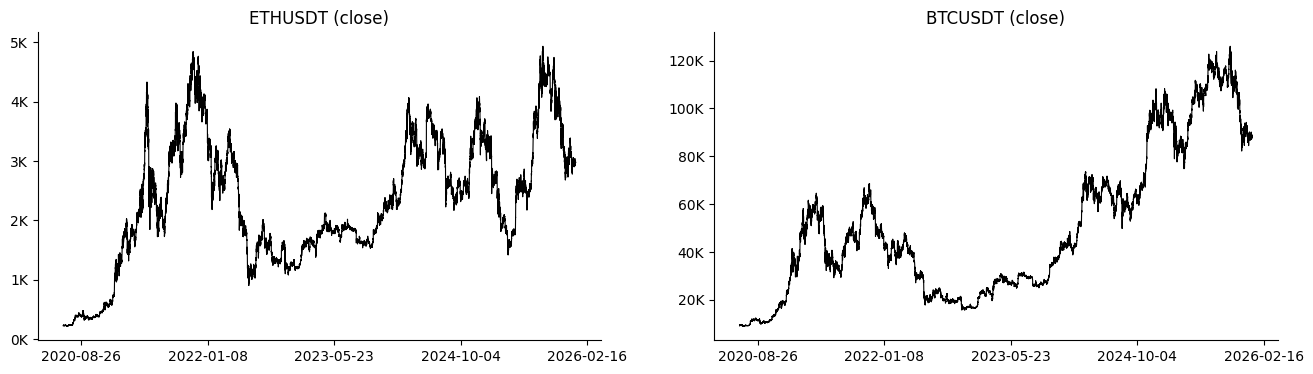

In [10]:
for k in dfs:
    dfs[k] = dfs[k][(dfs[k].index >= "2020-06-15 00:00:0") & (dfs[k].index <= "2026-01-01")]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, symbol in zip(axes, symbols):
    df = dfs[(symbol, "1h")]
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_formatter(lambda x, _: f"{x/1000:.0f}K")
    ax.plot(df.index, df["close"], color="black", linewidth=0.8)
    ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=5))
    ax.set_title(f"{symbol} (close)")
plt.show()

In [5]:
import math

def plot_grid(dfs, cols, max_points=50000, mode="cumsum", ncols=2):
    items = list(dfs.items())
    n = len(items)
    nrows = math.ceil(n / ncols)

    fig = plt.figure(figsize=(14 * ncols, 8 * nrows))
    outer = fig.add_gridspec(nrows, ncols, hspace=0.4, wspace=0.2)

    for idx, ((symbol, b), df) in enumerate(items):
        step = max(1, len(df) // max_points)
        df = df.iloc[::step].copy().sort_index()

        inner = outer[idx // ncols, idx % ncols].subgridspec(2, 1, height_ratios=[6, 2], hspace=0)
        ax = fig.add_subplot(inner[0])
        ax_vol = fig.add_subplot(inner[1], sharex=ax)

        ax.plot(df.index, df["close"], label="close", linewidth=0.8, color="black")
        ax.axvline(pd.Timestamp("2022-09-15 19:00:00"), color="grey", linestyle="--", linewidth=0.8)
        ax.axvline(pd.Timestamp("2022-08-12 19:00:00"), color="darkgrey", linestyle="--", linewidth=0.8)
        ax2 = ax.twinx()
        for col in cols:
            s = df[col].copy()
            series = s.cumsum() if mode == "cumsum" else s.resample("1D").max()
            ax2.plot(series.index if mode != "cumsum" else df.index, series, label=col, linewidth=0.8)
        ax.set_title(f"{symbol} {b}")
        ax2.legend(loc="upper left")

        colors = np.where(df["volume"].diff() >= 0, "green", "red")
        width = (df.index[-1] - df.index[0]) / len(df) * 0.8
        ax_vol.axvline(pd.Timestamp("2022-09-15 19:00:00"), color="grey", linestyle="--", linewidth=0.8)
        ax_vol.axvline(pd.Timestamp("2022-08-12 19:00:00"), color="darkgrey", linestyle="--", linewidth=0.8)
        ax_vol.set_ylim(0, df["volume"].quantile(0.995) * 1.2)
        ax_vol.bar(df.index, df["volume"], color=colors, width=width, edgecolor=colors, linewidth=0)
        plt.setp(ax.get_xticklabels(), visible=False)

    fig.autofmt_xdate()
    plt.show()

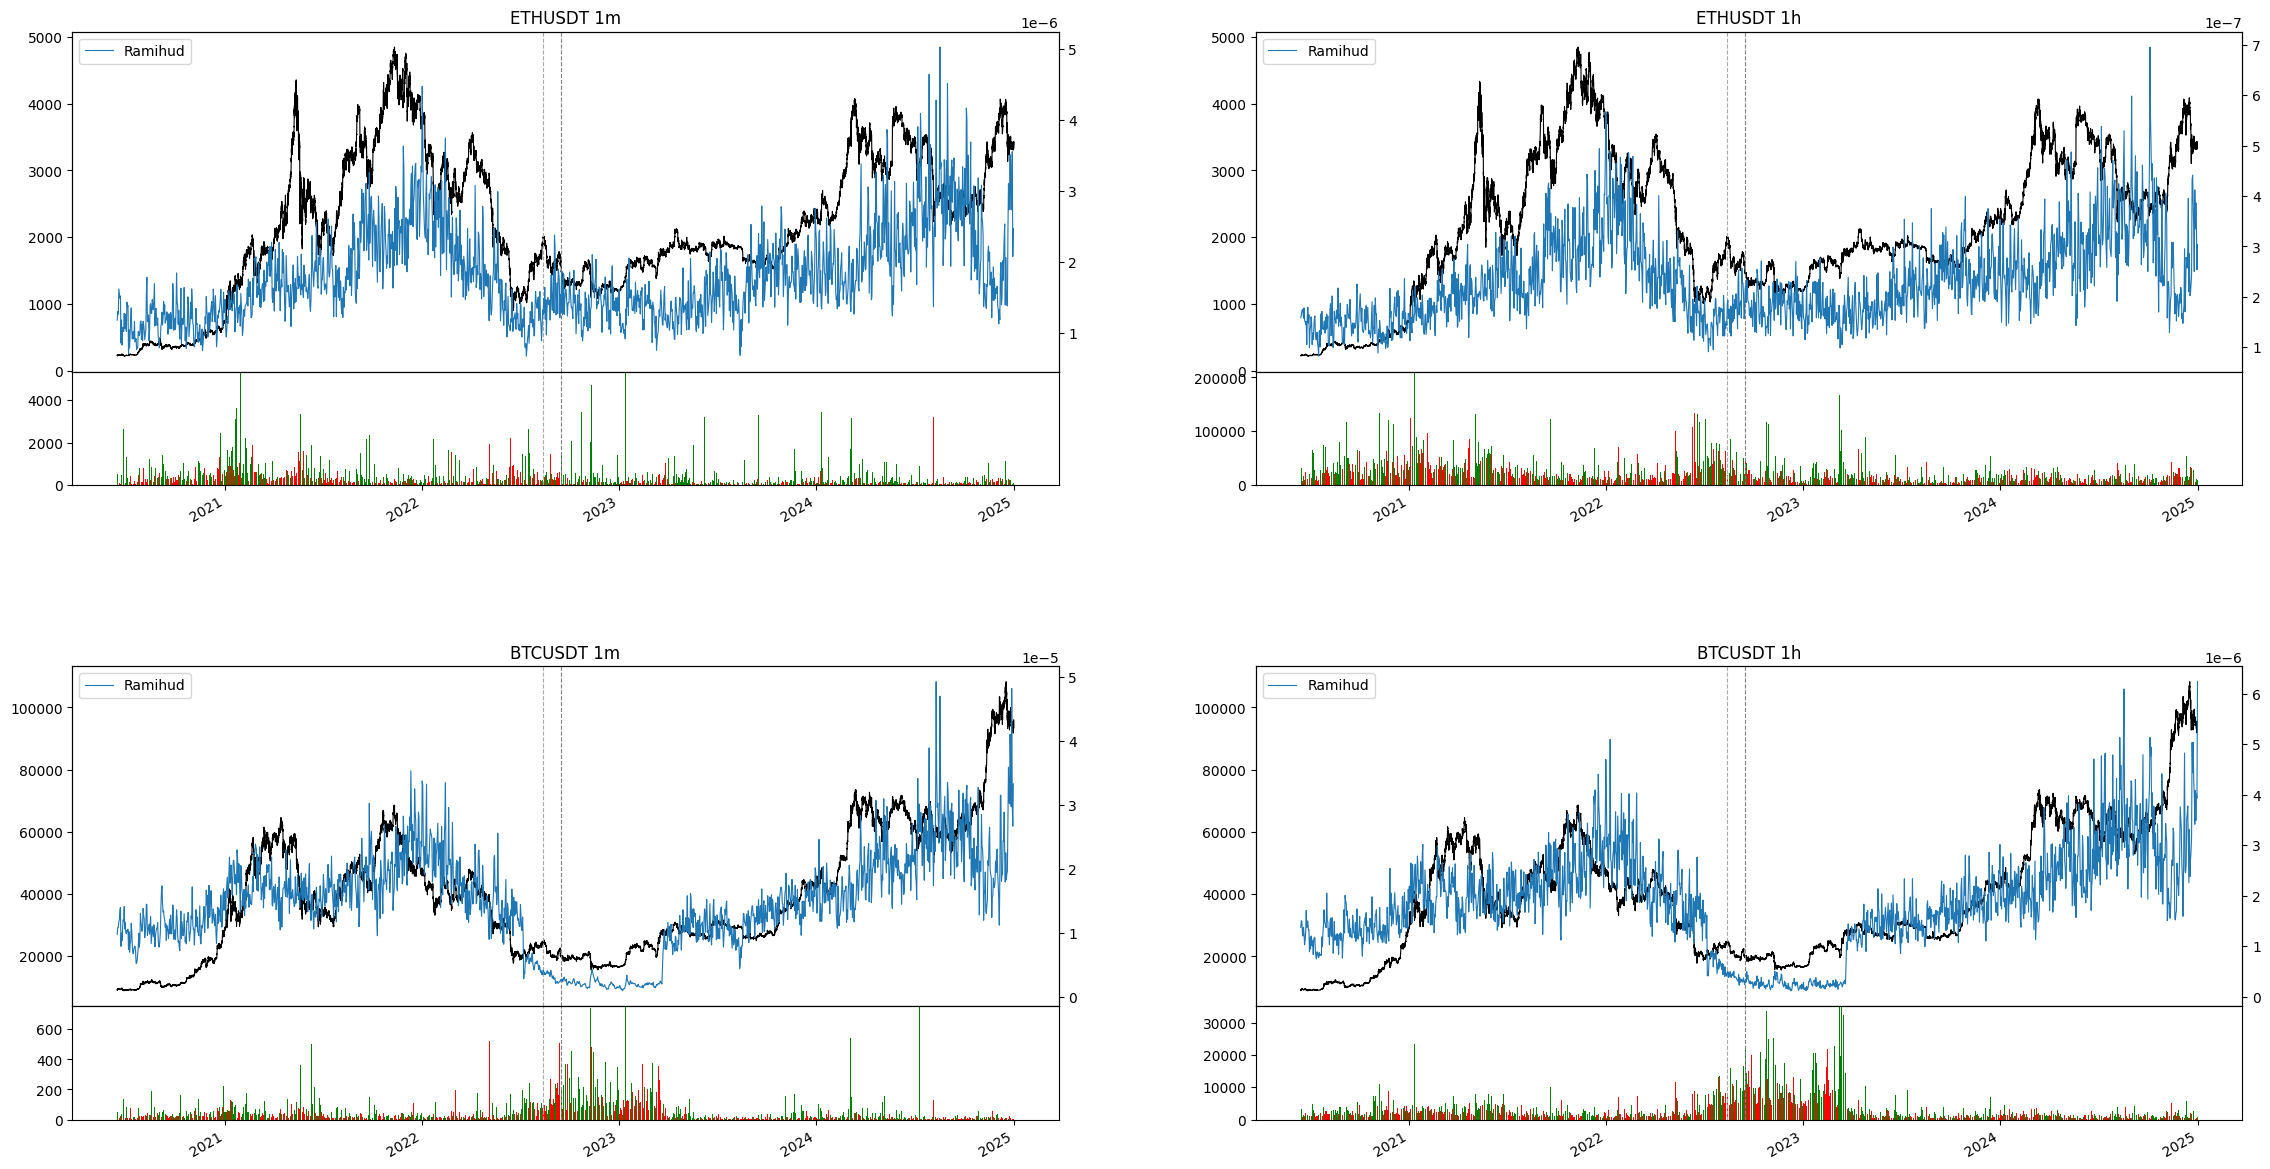

In [16]:
plot_grid(dfs, cols=['Ramihud'], mode="raw")

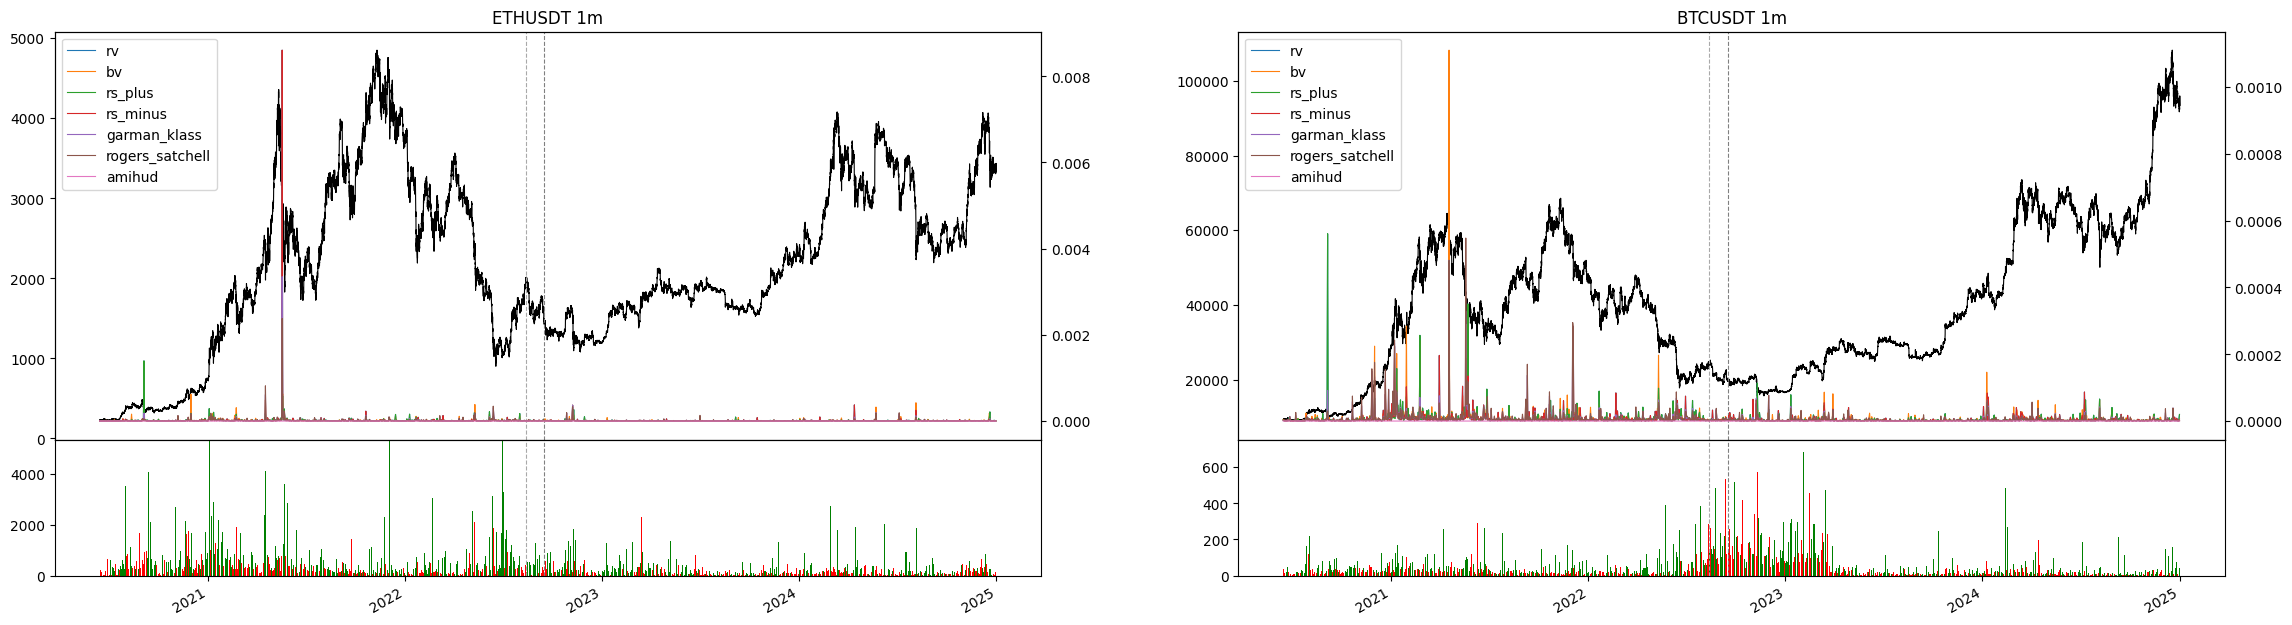

In [17]:
sub = {("ETHUSDT", "1m"): dfs[("ETHUSDT", "1m")], ("BTCUSDT", "1m"): dfs[("BTCUSDT", "1m")]}
plot_grid(sub, cols=['rv', 'bv', 'rs_plus', 'rs_minus', 'garman_klass', 'rogers_satchell', 'amihud'], mode="raw")

Note: 
Bogousslavsky, Collin-Dufresne: étude des order flow imbalance à haute fréquence et du observed spread, ainsi que des pricing errors inter-currencies. Ici, on ne dispose pas des données OB (on pourrait les reconstruire, mais lourd). On pourrait étudier les miss-pricing inter-exchanges, mais ce n'est pas vraiment lié au merge.